# Mock Test 3

In [3]:
def logger(func):
    def wrapper():
        print("hello world")
        func()
        print("How are you")
    return wrapper

@logger
def summ(a=4, b=3):
    print(a+b)

summ()

hello world
7
How are you


## Question 1 — Exception Handling

Write a Python program to simulate an ATM withdrawal.

Requirements:

- Create a variable for account balance.
- Ask the user for withdrawal amount.
- If withdrawal amount is greater than balance:
  - Raise a custom exception:
  
```python
InsufficientBalanceError
```

- Handle invalid input (example: user enters `"abc"` instead of a number).
- Always display:

```
Transaction Completed
```

using a `finally` block.

Example:

```
Enter withdrawal amount: 5000

Withdrawal successful
Remaining balance: 5000

Transaction Completed
```

or

```
Enter withdrawal amount: 15000

Insufficient balance

Transaction Completed
```



In [ ]:
class InsufficientBalanceError(Exception):
    pass 

balance = 5000

try:
    amount = int(input("Enter withdrawal amount: "))
    if amount> balance:
        raise InsufficientBalanceError("insufficient Balance")

    balance -= amount 
    print("Withdrawal Succesfull")

except InsufficientBalanceError as e:
    print(e)

except ValueError:
    print("Invalid Input")

finally:
    print("Transaction Completed")

    

Question 2 — Merge Two Sorted Linked Lists
You are given two sorted linked lists.
- Example:
- List1:
1 → 3 → 5

List2:
- 2 → 4 → 6

Output:
- 1 → 2 → 3 → 4 → 5 → 6

Requirements:
- Merge them into one sorted linked list.
- Return the head.
- Do not create new nodes.
- Reuse existing nodes.

Write your Python solution. (You can create a ListNode class first.)

In [1]:
class ListNode:
    def __init__(self, val):
        self.val = val 
        self.next = None 

    def insert(self, val):
        curr = self
        while curr.next:
            curr = curr.next
        curr.next = ListNode(val)


def merge_sorted_list(head1, head2):

    dummy = ListNode(0)
    current = dummy

    while head1 and head2:
        if head1.val <= head2.val:
            current.next = head1 

            head1 = head1.next
        else:
            current.next = head2 
            head2 = head2.next 

        current = current.next 

    current.next = head1 or head2 

    return dummy.next 

node1 = ListNode(1)
node2 = ListNode(2)

node1.insert(3)
node1.insert(5)
node2.insert(4)
node2.insert(6)

merged_list = merge_sorted_list(node1, node2)
while merged_list:
    print(f"{merged_list.val} ->", end=" ")
    merged_list = merged_list.next

print("None")


1 -> 2 -> 3 -> 4 -> 5 -> 6 -> None


## Question 3 — Descriptive Statistics

**High Probability ⭐⭐⭐⭐**

Given the following marks of students:

```
marks = np.array([45, 56, 67, 67, 72, 78, 81, 85, 90, 95])
```

Write a Python program to calculate:

- Mean
- Median
- Mode
- Minimum
- Maximum
- Range
- Variance
- Standard deviation

Also create:

- A histogram of the marks
- A box plot to identify possible outliers

Use NumPy, Matplotlib, and an appropriate method to calculate the mode.


Mean:  73.6
Median:  75.0
Mode:  67
Minimum:  45
Maximum:  95
Range:  50
Variance:  214.84
Standard Deviation:  14.6574213284602


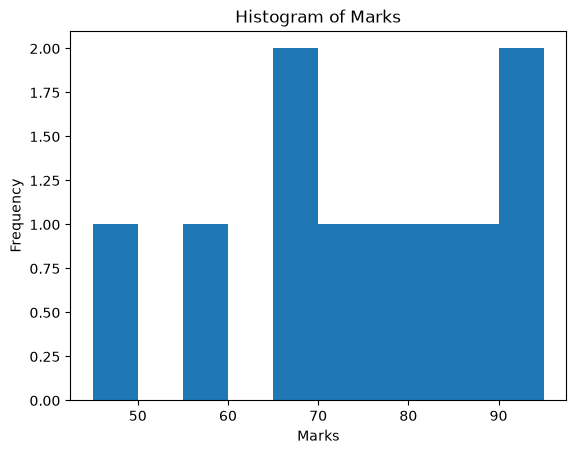

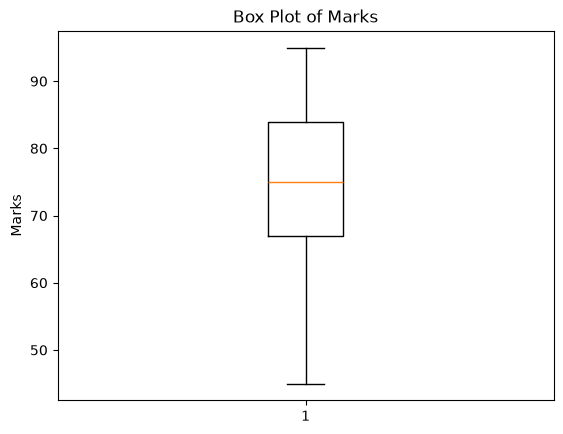

In [3]:
import numpy as np
import matplotlib.pyplot as plt

marks = np.array([45, 56, 67, 67, 72, 78, 81, 85, 90, 95])

print("Mean: ", np.mean(marks))
print("Median: ", np.median(marks))

values, counts = np.unique(marks, return_counts=True)
mode = values[np.argmax(counts)]
print("Mode: ", mode)

print("Minimum: ", np.min(marks))
print("Maximum: ", np.max(marks))
print("Range: ", np.max(marks) - np.min(marks))
print("Variance: ", np.var(marks))
print("Standard Deviation: ", np.std(marks))

plt.hist(marks)
plt.title("Histogram of Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

plt.boxplot(marks)
plt.title("Box Plot of Marks")
plt.ylabel("Marks")
plt.show()

## Question 1 — End-to-End Classification using Titanic Dataset (Very High Probability ⭐⭐⭐⭐⭐)

**Task:**

Using the Titanic dataset, create a Jupyter Notebook that demonstrates the complete Machine Learning workflow for predicting passenger survival.

### Requirements

1. Load the Titanic dataset.
2. Perform Exploratory Data Analysis (EDA).
    - Display dataset information.
    - Check missing values.
    - Visualize the target distribution.
3. Perform Data Cleaning.
    - Handle missing values.
    - Remove duplicates (if any).
4. Perform Feature Engineering.
    - Encode categorical variables.
    - Scale numerical features where necessary.
    - Select useful features.
5. Split the dataset into training and testing sets.
6. Build a classification model using **Random Forest Classifier**.
7. Perform hyperparameter tuning using **GridSearchCV**.
8. Evaluate the model using:
    - Accuracy
    - Precision
    - Recall
    - F1-Score
    - Confusion Matrix
    - Classification Report
9. Display the best hyperparameters and final model performance.
10. Briefly conclude the results.

**Libraries expected**

```
pandas
numpy
matplotlib
seaborn
sklearn
```

---


In [7]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [9]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

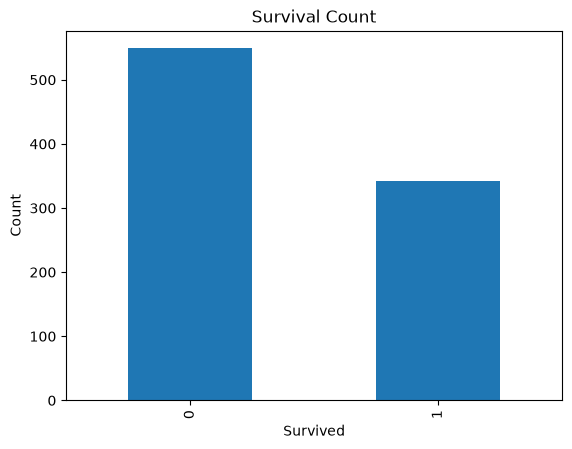

In [13]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [15]:
df = df.drop_duplicates()

In [17]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

In [18]:
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Sex", "Embarked"]

In [19]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [20]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

In [21]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    "classifier__n_estimators": [100, 200], 
    "classifier__max_depth": [None, 5, 10], 
    "classifier__min_samples_split": [2, 5]
}

In [24]:
grid = GridSearchCV(
    model, 
    param_grid, 
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [25]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [26]:
y_pred = grid.predict(X_test)

In [27]:
print("Best Parameters: ", grid.best_params_)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Best Parameters:  {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Accuracy:  0.8100558659217877
Precision:  0.8181818181818182
Recall:  0.6521739130434783
f1_score:  0.7258064516129032
Confusion Matrix:  [[100  10]
 [ 24  45]]
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179

